<a href="https://colab.research.google.com/github/seonghoyu11/csci-473-files/blob/main/Lab2/Steve_Yoo_Fall2026_473_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tensor Calculus and Statistical Applications
**Recitation by Dr. Fangshuo (Jasper) Liao**

_09/11/2026, 09:30, 14:00_

## Practical Aspects of Probability

### Sampling

Sampling from distributions is crucial in ML:

 - Neural network initialization
 - Generative models
 - Training involves data sampling

PyTorch provides ways to sample from distributions in [torch.distributions](https://docs.pytorch.org/docs/2.14/distributions.html). Next, we will look at some examples.

In [ ]:
import torch
import matplotlib.pyplot as plt

### Sample 1D Gaussian

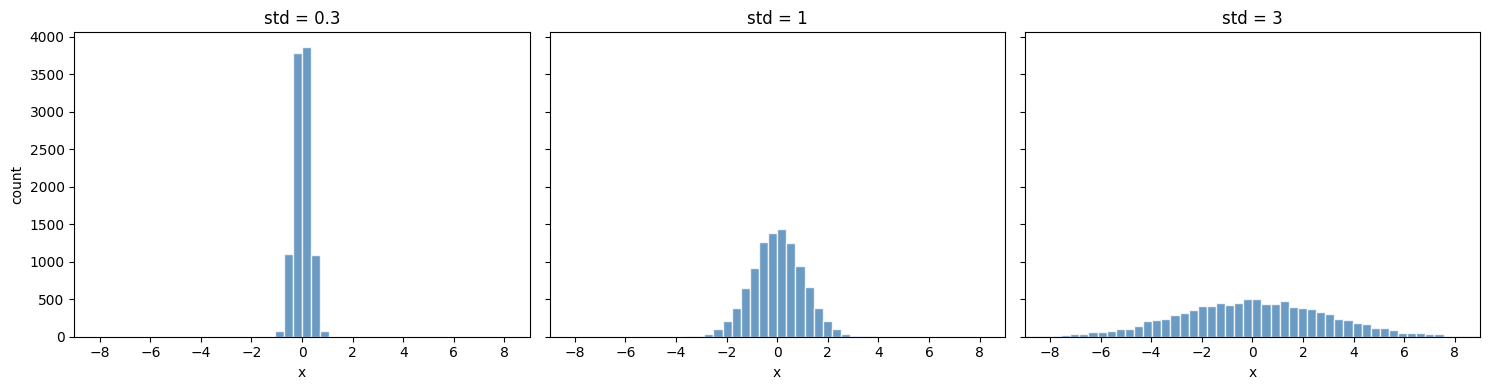

In [ ]:
from torch.distributions import Normal

n_samples = 10000
stds = [0.3, 1, 3] # We will be generating 3 Gaussian distributions, with std {0.3, 1, 3}
x_range = (-9, 9)  # common x-range wide enough for std=3 (~3 sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, std in zip(axes, stds): # Iterate over the std values
    dist = Normal(loc=0.0, scale=float(std))  # Create Gaussian distribution
    samples = dist.sample((n_samples,))       # shape: (n_samples,)

    ax.hist(samples, bins=50, range=x_range, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f"std = {std}")
    ax.set_xlabel("x")
    ax.set_xlim(x_range)

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

### Sample 2D Gaussian

For 1D distributions, the mean and variance are scalars. For 2-dimensional distributions, the mean is a vector in $\mathbb{R}^2$ and (co)variance a matrix in $\mathbb{R}^{2\times 2}$.

In [ ]:
from torch.distributions import MultivariateNormal

n_samples = 1000
mean = torch.tensor([0.0, 0.0])
covariances = [
    torch.tensor([[1.0, 0.0], [0.0, 1.0]]),
    torch.tensor([[4.0, 0.0], [0.0, 1.0]]),
    torch.tensor([[5.0, 3.0], [3.0, 5.0]]),
]
titles = [
    "cov = [[1,0],[0,1]]",
    "cov = [[4,0],[0,1]]",
    "cov = [[5,1],[1,5]]",
]

print("Covariance 1: \n", covariances[0])
print("Covariance 2: \n", covariances[1])
print("Covariance 3: \n", covariances[2])

Covariance 1: 
 tensor([[1., 0.],
        [0., 1.]])
Covariance 2: 
 tensor([[4., 0.],
        [0., 1.]])
Covariance 3: 
 tensor([[5., 3.],
        [3., 5.]])


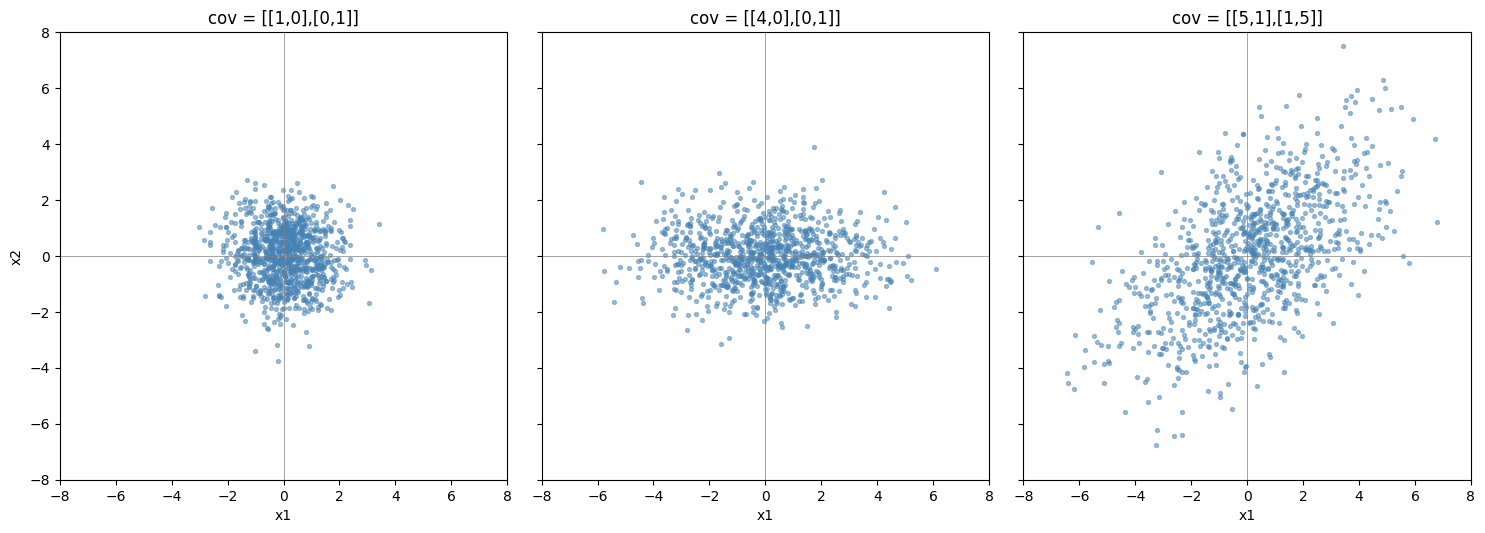

In [ ]:
axis_range = (-8, 8)  # shared x/y range across all subplots

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, cov, title in zip(axes, covariances, titles):
    dist = MultivariateNormal(loc=mean, covariance_matrix=cov)
    samples = dist.sample((n_samples,))   # shape: (n_samples, 2)
    x, y = samples[:, 0].numpy(), samples[:, 1].numpy()

    ax.scatter(x, y, s=8, alpha=0.5, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_xlim(axis_range)
    ax.set_ylim(axis_range)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

axes[0].set_ylabel("x2")
plt.tight_layout()
plt.show()

### Random Seeds

Using torch.manual_seed to set the random seed used for sampling. Same seed guarantees the same sampling result.

In [ ]:
import torch

# torch.manual_seed(31)
x = torch.randn(1)
print('x=', x)

x= tensor([1.2483])


### A Note on n-Dimensional Random Vectors

If $\mathbf{x}\in\mathbb{R}^d$ is an d-dimensional random vector, then its mean is
$$
  \mathbf{\mu} := \mathbb{E}[\mathbf{x}]\in\mathbb{R}^d;\;\;\text{such that}\;\; \mu_i = \mathbb{E}[x_i]
$$

Its (co)variance is

$$
  \mathbf{\Sigma} := \mathbb{E}[(\mathbf{x} - \mathbf{\mu})(\mathbf{x} - \mathbf{\mu})^\top] \in \mathbb{R}^{d\times d};\;\;\text{such that}\;\; \Sigma_{ij} = \text{Cov}(x_i, x_j)
$$

### Computing Statistics

**Computing mean:** We covered ways to compute the mean of $n$ random vectors $x_1, \dots x_n\in\mathbb{R}^d$ last week by using torch.mean and set the correct axis.

**Computing entry-wise std:** If we want to estimate a vector $\mathbf{\sigma}$ such that $\mathbf{\sigma}[j] = \text{Var}(x[j])$, then this is also covered last week by using torch.std / torch.var and set the correct axis.

**Computing the full covariance matrix:** If we want to estimate $\mathbf{\Sigma}\in\mathbb{R}^{d\times d}$ so that $\Sigma[i,j] = \text{Cov}(x_i, x_j)$, we need to use the following estimator:

$$
  \mathbf{\Sigma} \approx \frac{1}{n-1}\sum_{i=1}^n(x_i - \mu)(x_i - \mu)^\top
$$
Or directly use torch.cov.

Distribution mean: tensor([1., 2.])
Distribution covariance: 
 tensor([[3., 1.],
        [1., 3.]])
torch.Size([10000, 2])


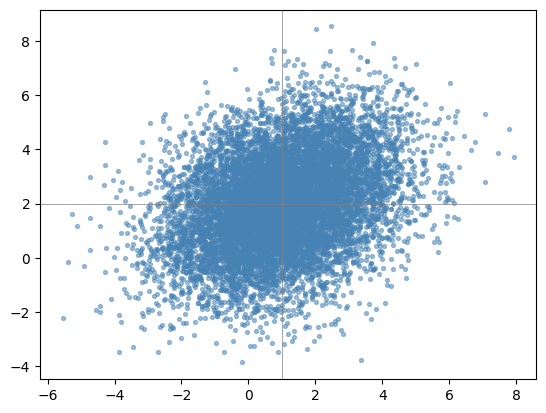

In [ ]:
# Define a ground truth mean and covariance
x_cov = torch.tensor([[3, 1], [1, 3]], dtype=torch.float32)
x_mean = torch.tensor([1, 2], dtype=torch.float32)

print('Distribution mean:', x_mean)
print('Distribution covariance: \n', x_cov)

# Sample n = 10000 x.

n = 10000
x_dist = MultivariateNormal(loc=x_mean, covariance_matrix=x_cov)
x_samples = x_dist.sample((n,))

print(x_samples.shape)

ax = plt.gca()
ax.scatter(x_samples[:,0], x_samples[:,1], s=8, alpha=0.5, color='steelblue')
ax.axhline(2, color='gray', lw=0.5)
ax.axvline(1, color='gray', lw=0.5)
plt.show()

In [ ]:
# Compute the mean
est_mean = torch.mean(x_samples, axis=0)
print('Estimated mean: ', est_mean)

Estimated mean:  tensor([0.9989, 2.0348])


In [ ]:
# Compute the entry-wise variance
est_entry_var = torch.var(x_samples, axis=0)
print('Estimated entry-wise variance:', est_entry_var)

Estimated entry-wise variance: tensor([2.9549, 3.0414])


In [ ]:
# Compute the full covariance
est_cov_manual = (x_samples - est_mean).T @ (x_samples - est_mean) / (n-1)
print('Estimated full covariance (manual computation): \n', est_cov_manual)

Estimated full covariance (manual computation): 
 tensor([[2.9549, 0.9565],
        [0.9565, 3.0414]])


In [ ]:
# Compute the full covariance with torch.cov
est_cov_torch = torch.cov(x_samples.T)
print('Estimated full covariance (pytorch): \n', est_cov_torch)

Estimated full covariance (pytorch): 
 tensor([[2.9549, 0.9565],
        [0.9565, 3.0414]])


## Vector Calculus

Recall that for $f: \mathbb{R}\rightarrow \mathbb{R}$, its derivative $f'(x)$ represents the "slope" of the function at $x$. Vector calculus takes that idea to $f: \mathbb{R}^m\rightarrow \mathbb{R}^n$.

### Gradient

For a function $f: \mathbb{R}^m\rightarrow \mathbb{R}$, its gradient is
$$
  \nabla f(\mathbf{x}) \in\mathbb{R}^m ;\quad [\nabla f(\mathbf{x})]_i = \frac{\partial f(\mathbf{x})}{\partial x_i}
$$
Here $\frac{\partial f(\mathbf{x})}{\partial x_i}$ is the partial derivative. To compute $\frac{\partial f(\mathbf{x})}{\partial x_i}$, you treat only $x_i$ as the variable and all other $x_1, ... x_{i-1}, x_{i+1}, ... x_m$ as constants.

**Example:** $f(\mathbf{x}) = x_1^2 + 2x_1x_2$ for $\mathbf{x} = [x_1, x_2]\in\mathbb{R}^2$.

Compute the partial derivative:
$$
 \frac{\partial f(\mathbf{x})}{\partial x_1} = 2x_1 + 2x_2;\;\; \frac{\partial f(\mathbf{x})}{\partial x_2} = 2x_1
$$
Putting together the partial derivatives to get the gradient:
$$
  \nabla f(\mathbf{x}) = \begin{bmatrix}2x_1 + 2x_2\\ 2x_2\end{bmatrix} \in \mathbb{R}^2
$$

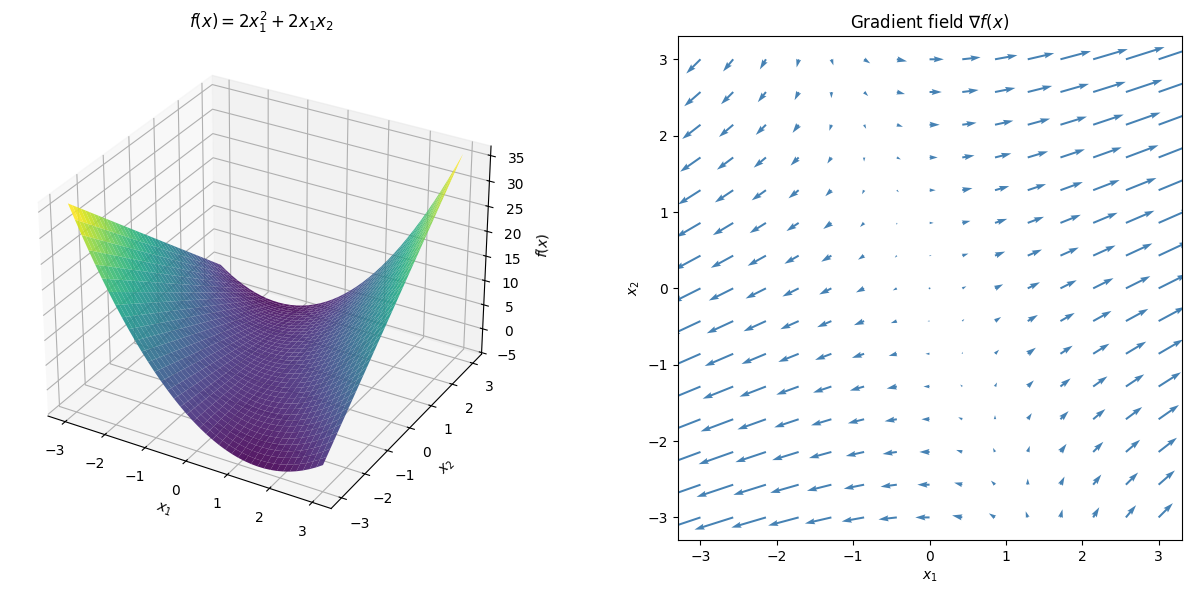

In [ ]:
import torch
import matplotlib.pyplot as plt


def f(x1, x2):
    return 2 * x1 ** 2 + 2 * x1 * x2


def grad_f(x1, x2):
    """Manually implemented gradient of f(x1, x2) = 2*x1^2 + 2*x1*x2.

    d f / d x1 = 4*x1 + 2*x2
    d f / d x2 = 2*x1
    """
    df_dx1 = 4 * x1 + 2 * x2
    df_dx2 = 2 * x1
    return df_dx1, df_dx2


# ---------------------------------------------------------------
# 1) Fine grid for the 3D surface (torch, no numpy)
# ---------------------------------------------------------------
n_surf = 40
x1 = torch.linspace(-3, 3, n_surf)
x2 = torch.linspace(-3, 3, n_surf)
X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
Z = f(X1, X2)

# ---------------------------------------------------------------
# 2) Coarser grid for the gradient vector field, gradients
#    computed with the manually implemented grad_f (no autograd)
# ---------------------------------------------------------------
n_vec = 15
g1 = torch.linspace(-3, 3, n_vec)
g2 = torch.linspace(-3, 3, n_vec)
G1, G2 = torch.meshgrid(g1, g2, indexing="xy")

dfdx1, dfdx2 = grad_f(G1, G2)   # d f / d x1, d f / d x2 at each grid point

# ---------------------------------------------------------------
# 3) Plotting
# ---------------------------------------------------------------
fig = plt.figure(figsize=(13, 6))

# --- Left: 3D surface -------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(
    X1.numpy(), X2.numpy(), Z.numpy(),
    cmap="viridis", edgecolor="none", alpha=0.9
)
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_zlabel(r"$f(x)$")
ax1.set_title(r"$f(x) = 2x_1^2 + 2x_1 x_2$")

# --- Right: gradient vector field --------------------------------------
ax2 = fig.add_subplot(1, 2, 2)
ax2.quiver(
    G1.numpy(), G2.numpy(),
    dfdx1.numpy(), dfdx2.numpy(),
    color="steelblue"
)
ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_title(r"Gradient field $\nabla f(x)$")
ax2.set_aspect("equal")

plt.tight_layout()
plt.savefig("surface_and_gradient.png", dpi=150)
plt.show()

**Example:** $f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x}$ for some $\mathbf{w}\in\mathbb{R}^m$.

Compute the partial derivative for each $x_i$

$$
  f(\mathbf{x}) = \sum_{i=1}^mw_ix_i;\;\Rightarrow\; \frac{\partial f(\mathbf{x})}{\partial x_i} = \frac{\partial w_1x_1}{\partial x_i} + \dots + \frac{\partial w_ix_i}{\partial x_i} + \dots + \frac{\partial w_mx_m}{\partial x_i} = w_i
$$
Putting together the partial derivatives to get the gradient
$$
  \nabla f(\mathbf{x}) = \begin{bmatrix} w_1\\ \vdots \\ w_m\end{bmatrix} = \mathbf{w}
$$

### Jacobian
Now we move on to the case $f: \mathbb{R}^m \rightarrow \mathbb{R}^n$. The notation of the derivative becomes a matrix called the Jacobian of $f$.
$$
  \mathbf{J}_f(\mathbf{x}) \in \mathbb{R}^{n\times m};\quad \mathbf{J}_f(\mathbf{x})_{ij} = \frac{\partial f(\mathbf{x})_i}{\partial x_j}
$$

**Example:** $f(\mathbf{x}) = \begin{bmatrix}x_1^2\\ x_1 + 2x_2x_3\end{bmatrix}$ for $\mathbf{x} = [x_1, x_2, x_3]\in\mathbb{R}^3$.

We read $f(\mathbf{x})_1 = x_1^2$ and $f(\mathbf{x})_2 = x_1 + 2x_2x_3$ Compute partial derivatives:
$$
  \frac{\partial f(\mathbf{x})_1}{\partial x_1} = 2x_1;\; \frac{\partial f(\mathbf{x})_1}{\partial x_2} = 0;\; \frac{\partial f(\mathbf{x})_1}{\partial x_3} = 0
$$
And
$$
  \frac{\partial f(\mathbf{x})_2}{\partial x_1} = 1;\; \frac{\partial f(\mathbf{x})_2}{\partial x_2} = 2x_3;\; \frac{\partial f(\mathbf{x})_1}{\partial x_3} = 2x_2
$$
Putting together to get the Jacobian
$$
  \mathbf{J}_f(\mathbf{x}) = \begin{bmatrix} 2x_1 & 0 & 0\\ 1 & 2x_3 & 2x_2\end{bmatrix}
$$

**Example:** $f(\mathbf{x}) = \mathbf{A}\mathbf{x}$ for $\mathbf{x}\in\mathbb{R}^m$ and $\mathbf{A} \in\mathbb{R}^{n\times m}$.

From last week, $f(\mathbf{x})_i = [\mathbf{A}\mathbf{x}]_i = \sum_{j=1}^mA_{ij}x_j$. Compute the partial derivatives:
$$
  \frac{\partial f(\mathbf{x})_i}{\partial x_j} = \frac{\partial A_{i1}x_1}{\partial x_j} + \dots + \frac{\partial A_{ij}x_j}{\partial x_j} + \dots + \frac{\partial A_{im}x_m}{\partial x_m} = A_{ij}
$$
Then we know that $\mathbf{J}_f(\mathbf{x})_{ij} = A_{ij}$, which implies that
$$
  \mathbf{J}_f(\mathbf{x}) = \mathbf{A} \in\mathbb{R}^{n\times m}
$$

**Why do you need to know about Jacobian?** Two reasons:

- It is used to define the Hessian matrix of a function, which is crucial to ML (later).
- It can help you compute the gradient (today).

### Relationship between Jacobian and Gradient

Gradient is defined for $f: \mathbb{R}^m\rightarrow \mathbb{R}$, which is the case where $n = 1$ in the setting above. Let $f: \mathbb{R}^m\rightarrow \mathbb{R}$. If we view vectors as column vectors, then
$$
  \nabla f(\mathbf{x}) \in \mathbb{R}^{m\times 1};\;\; \mathbf{J}_f(\mathbf{x}) \in \mathbb{R}^{1\times m}
$$
There all contains partial derivatives $\frac{\partial f(\mathbf{x})}{\partial x_i}$, so $\nabla f(\mathbf{x}) = \mathbf{J}_f(\mathbf{x})^\top$.


### Chain-rule of Jacobian

Let $f: \mathbb{R}^{m}\rightarrow \mathbb{R}^n$ and $g:\mathbb{R}^n\rightarrow \mathbb{R}^p$. Then $h = f\circ g: \mathbb{R}^m\rightarrow \mathbb{R}^p$ with
$$
  h(\mathbf{x}) = g(f(\mathbf{x}))
$$
The Jacobian of $h$ is related to the Jacobian of $f$ and $g$ as
$$
  \mathbf{J}_h(\mathbf{x}) = \mathbf{J}_g(f(\mathbf{x}))\mathbf{J}_f(\mathbf{x})
$$

**Example:** $h(\mathbf{x}) = \|\mathbf{A}\mathbf{x}\|_2^2$ for $\mathbf{x}\in\mathbb{R}^m$ and $\mathbf{A} \in \mathbb{R}^{n\times m}$. Compute $\nabla h(\mathbf{x})$.

Define $f: \mathbb{R}^{m}\rightarrow \mathbb{R}^n$ as $f(\mathbf{x}) = \mathbf{A}\mathbf{x}$ and $g: \mathbb{R}^n\rightarrow \mathbb{R}$ as $g(\mathbf{v}) = \|\mathbf{v}\|_2^2$. From previous example we know that
$$
  \mathbf{J}_f(\mathbf{x}) = \mathbf{A}
$$
A simple computation (left as an exercise) gives
$$
  \nabla g(\mathbf{v}) = 2\mathbf{v};\;\;\mathbf{J}_g(\mathbf{v}) = 2\mathbf{v}^\top
$$
Apply the chain-rule (with $\mathbf{v} = f(\mathbf{x})= \mathbf{A}\mathbf{x}$)
$$
  \mathbf{J}_h(\mathbf{x}) = \mathbf{J}_g(\mathbf{A}\mathbf{x})\mathbf{J}_f(\mathbf{x}) = 2(\mathbf{A}\mathbf{x})^\top \mathbf{A} = 2\mathbf{x}^\top\mathbf{A}^\top\mathbf{A}
$$
Transpose to obtain the gradient
$$
  \nabla h(\mathbf{x}) = 2\mathbf{A}^\top\mathbf{A}\mathbf{x}
$$

## **Exercise!**

### Exercise 1
Given a vector $v\in\mathbb{R}^d$, do the following:

- Sample $n$ vectors $x_1, ... , x_n$ from $\mathbf{N}(0, vv^\top)$ using only the sampler torch.randn (i.e., you can only sample from standard Gaussian distributions). This should give a $n\times  d$ matrix. (Hint: what's the covariance matrix of Qx if x is a random vector and Q is a matrix?)

- Based on the samples in the previous step, estimate the covariance matrix. Compare it to $vv^\top$ by computing the norm of the difference.

In [ ]:
d = 100
n = 100000

v = torch.randn((d,)) / (d ** 0.5) # This is a fixed vector v that is provided to you.
X_raw = torch.randn((n, d))


## Your code here
v_norm = torch.norm(v)
Q = torch.outer(v, v) / v_norm

X = X_raw @ Q
cov_est = torch.cov(X.T)
true_cov = torch.outer(v,v)

diff_norm = torch.norm(cov_est - true_cov)

print(X.shape)
print(diff_norm)

torch.Size([100000, 100])
tensor(0.0016)


### Exercise 2

Let $h(\mathbf{x}) = \|\mathbf{A}\mathbf{x} - \mathbf{b}\|_2^2$ for $\mathbf{x}\in\mathbb{R}^m, \mathbf{A}\in\mathbb{R}^{n\times m}$ and $\mathbf{b}\in\mathbb{R}^n$.

*   Compute $\nabla h(\mathbf{x})$ by hand. Implement a function in pytorch that, given input $\mathbf{x}$, returns $\nabla h(\mathbf{x})$.
*   The finite difference method to estimate the gradient uses the finite difference to estimate each partial derivative by $\frac{\partial h(\mathbf{x})}{\partial x_i}  \approx \frac{h(\mathbf{x + \epsilon \mathbf{e}_i}) - h(\mathbf{x})}{\epsilon}
$ for a very small $\epsilon \in\mathbb{R}$, and then put together the estimated partial derivatives to get the estimated gradient. Implement the finite difference method to estimate the gradient at a fixed point $\mathbf{x}_0$. Compute the $\ell_2$-norm difference between the gradient estimated by the finite difference method and the gradient computed by hand.


In [ ]:
m, n = (15, 20)

A = torch.randn((n, m)) / (n ** 0.5)
b = torch.randn((n,)) / (n ** 0.5)

def h(x):
  return torch.norm(A @ x - b) ** 2


# Implement the gradient function with the closed-form computed by hand.
def h_grad(x):
  # Your code goes below (revise the return statement).
  return 2 * A.T @ (A @ x - b)


# Implement the finite difference method to estimate the gradient at a point x_0
x_0 = torch.randn((m,)) / (m ** 0.5)
epsilon = 1e-3

def e_i(i, dim):
  '''
  Returns the ith standard basis vector e_i in R^d
  '''
  e_vec = torch.zeros((m,))
  e_vec[i] = 1
  return e_vec

# Your code goes here
grad_fd = torch.zeros((m,))
for i in range(m):
  grad_fd[i] = (h(x_0 + epsilon * e_i(i, m)) - h(x_0)) / epsilon

grad_exact = h_grad(x_0)
diff = torch.norm(grad_fd - grad_exact)

print(grad_exact)
print(grad_fd)
print(diff)

tensor([-0.3884,  0.6822, -0.2645, -1.0803,  0.4860, -0.3535, -1.6010,  1.2350,
        -0.7445,  0.3111, -0.0217, -0.5999, -0.4121, -0.2633,  0.7060])
tensor([-0.3871,  0.6827, -0.2638, -1.0791,  0.4867, -0.3526, -1.5999,  1.2361,
        -0.7440,  0.3117, -0.0209, -0.5993, -0.4115, -0.2620,  0.7068])
tensor(0.0034)


## When You Are Done, Please Fill out the Following Form

https://forms.gle/mdyyXizUTUejdyw28